<a href="https://colab.research.google.com/github/yiding2022/DAAI/blob/main/Data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day1 Workshop: Managing and preparing data


In [1]:
# Import required libraries
# For analysis:
import numpy as np
import pandas as pd  # might require 'pip install openpyxl' to read Excel files
# For plotting:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

# Upload file
uploaded = files.upload()

Saving hflights.csv to hflights.csv


In [ ]:
# Check if the file was uploaded successfully
hflights = pd.read_csv('hflights.csv')

In [3]:
url = "https://raw.githubusercontent.com/yiding2022/DAAI/main/hflights.csv"
hflights = pd.read_csv(url)

In [4]:
hflights

,Unnamed: 0,Year,Month,DayofMonth,DayOfWeek,DepTime,ArrTime,UniqueCarrier,FlightNum,TailNum,...,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted
0,5424,2011,1,1,6,1400.0,1500.0,AA,428,N576AA,...,-10.0,0.0,IAH,DFW,224,7.0,13.0,0,NaN,0
1,5425,2011,1,2,7,1401.0,1501.0,AA,428,N557AA,...,-9.0,1.0,IAH,DFW,224,6.0,9.0,0,NaN,0
2,5426,2011,1,3,1,1352.0,1502.0,AA,428,N541AA,...,-8.0,-8.0,IAH,DFW,224,5.0,17.0,0,NaN,0
3,5427,2011,1,4,2,1403.0,1513.0,AA,428,N403AA,...,3.0,3.0,IAH,DFW,224,9.0,22.0,0,NaN,0
4,5428,2011,1,5,3,1405.0,1507.0,AA,428,N492AA,...,-3.0,5.0,IAH,DFW,224,9.0,9.0,0,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227491,6083255,2011,12,6,2,1818.0,2111.0,WN,1191,N284WN,...,-9.0,8.0,HOU,TPA,781,5.0,11.0,0,NaN,0
227492,6083256,2011,12,6,2,2047.0,2334.0,WN,1674,N366SW,...,4.0,7.0,HOU,TPA,781,4.0,9.0,0,NaN,0
227493,6083257,2011,12,6,2,912.0,1031.0,WN,127,N777QC,...,-4.0,-3.0,HOU,TUL,453,4.0,14.0,0,NaN,0
227494,6083258,2011,12,6,2,656.0,812.0,WN,621,N727SW,...,-13.0,-4.0,HOU,TUL,453,3.0,9.0,0,NaN,0


In [ ]:
# Variable definitions: https://www.rdocumentation.org/packages/hflights/versions/0.1/topics/hflights

### Preview data

In [5]:
# check the variables
hflights.info()

# show the first 5 rows, 8 columes
hflights.iloc[0:5, 0:8]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227496 entries, 0 to 227495
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         227496 non-null  int64  
 1   Year               227496 non-null  int64  
 2   Month              227496 non-null  int64  
 3   DayofMonth         227496 non-null  int64  
 4   DayOfWeek          227496 non-null  int64  
 5   DepTime            224591 non-null  float64
 6   ArrTime            224430 non-null  float64
 7   UniqueCarrier      227496 non-null  object 
 8   FlightNum          227496 non-null  int64  
 9   TailNum            226701 non-null  object 
 10  ActualElapsedTime  223874 non-null  float64
 11  AirTime            223874 non-null  float64
 12  ArrDelay           223874 non-null  float64
 13  DepDelay           224591 non-null  float64
 14  Origin             227496 non-null  object 
 15  Dest               227496 non-null  object 
 16  Di

,Unnamed: 0,Year,Month,DayofMonth,DayOfWeek,DepTime,ArrTime,UniqueCarrier
0,5424,2011,1,1,6,1400.0,1500.0,AA
1,5425,2011,1,2,7,1401.0,1501.0,AA
2,5426,2011,1,3,1,1352.0,1502.0,AA
3,5427,2011,1,4,2,1403.0,1513.0,AA
4,5428,2011,1,5,3,1405.0,1507.0,AA


### Select data

In [6]:
# select certain columes based on colume names

d1 = hflights.loc[:, ['ArrTime', 'DepTime']]  # alternative: hflights[['ArrTime', 'DepTime']]
d1.head()

,ArrTime,DepTime
0,1500.0,1400.0
1,1501.0,1401.0
2,1502.0,1352.0
3,1513.0,1403.0
4,1507.0,1405.0


In [7]:
# Helper Functions
# Using a regular expression (regex). regex='Time' means that the method will look for all columns whose names contain the string "Time".
# It is not case-sensitive, so it will match "Time", "ArrivalTime", "DepartureTime", etc.
d2 = hflights.filter(regex='Time')
d2.head()

,DepTime,ArrTime,ActualElapsedTime,AirTime
0,1400.0,1500.0,60.0,40.0
1,1401.0,1501.0,60.0,45.0
2,1352.0,1502.0,70.0,48.0
3,1403.0,1513.0,70.0,39.0
4,1405.0,1507.0,62.0,44.0


In [8]:
# regex='Time|Delay' means that the method will look for all columns whose names contain the string "Time" or "Delay".

d3 = hflights.filter(regex='Time|Delay')
d3.head()

,DepTime,ArrTime,ActualElapsedTime,AirTime,ArrDelay,DepDelay
0,1400.0,1500.0,60.0,40.0,-10.0,0.0
1,1401.0,1501.0,60.0,45.0,-9.0,1.0
2,1352.0,1502.0,70.0,48.0,-8.0,-8.0
3,1403.0,1513.0,70.0,39.0,3.0,3.0
4,1405.0,1507.0,62.0,44.0,-3.0,5.0


In [9]:
# Select variables that are in form of numbers
# select_dtypes is a method in pandas used to select columns in a DataFrame based on their data type.
# np.number is a general type that includes all numeric data types (like integers, floats, etc.).

d4 = hflights.select_dtypes(include=np.number)
d4.head()

,Unnamed: 0,Year,Month,DayofMonth,DayOfWeek,DepTime,ArrTime,FlightNum,ActualElapsedTime,AirTime,ArrDelay,DepDelay,Distance,TaxiIn,TaxiOut,Cancelled,Diverted
0,5424,2011,1,1,6,1400.0,1500.0,428,60.0,40.0,-10.0,0.0,224,7.0,13.0,0,0
1,5425,2011,1,2,7,1401.0,1501.0,428,60.0,45.0,-9.0,1.0,224,6.0,9.0,0,0
2,5426,2011,1,3,1,1352.0,1502.0,428,70.0,48.0,-8.0,-8.0,224,5.0,17.0,0,0
3,5427,2011,1,4,2,1403.0,1513.0,428,70.0,39.0,3.0,3.0,224,9.0,22.0,0,0
4,5428,2011,1,5,3,1405.0,1507.0,428,62.0,44.0,-3.0,5.0,224,9.0,9.0,0,0


In [10]:
d4.describe()

,Unnamed: 0,Year,Month,DayofMonth,DayOfWeek,DepTime,ArrTime,FlightNum,ActualElapsedTime,AirTime,ArrDelay,DepDelay,Distance,TaxiIn,TaxiOut,Cancelled,Diverted
count,2.274960e+05,227496.0,227496.000000,227496.000000,227496.000000,224591.000000,224430.000000,227496.000000,223874.000000,223874.000000,223874.000000,224591.000000,227496.000000,224430.000000,224549.000000,227496.000000,227496.000000
mean,3.021458e+06,2011.0,6.513662,15.737446,3.947691,1395.755614,1578.254106,1961.663141,129.323745,108.142335,7.094334,9.444951,787.783245,6.098855,15.091098,0.013068,0.002853
std,1.755914e+06,0.0,3.417676,8.782705,1.990272,448.322238,472.401715,1430.793403,59.285838,56.555231,30.708516,28.803615,453.680566,3.961069,7.740373,0.113568,0.053335
min,5.424000e+03,2011.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,34.000000,11.000000,-70.000000,-33.000000,79.000000,1.000000,1.000000,0.000000,0.000000
25%,1.555452e+06,2011.0,4.000000,8.000000,2.000000,1021.000000,1215.000000,855.000000,77.000000,58.000000,-8.000000,-3.000000,376.000000,4.000000,10.000000,0.000000,0.000000
50%,3.114682e+06,2011.0,7.000000,16.000000,4.000000,1416.000000,1617.000000,1696.000000,128.000000,107.000000,0.000000,0.000000,809.000000,5.000000,14.000000,0.000000,0.000000
75%,4.556825e+06,2011.0,9.000000,23.000000,6.000000,1801.000000,1953.000000,2755.000000,165.000000,141.000000,11.000000,9.000000,1042.000000,7.000000,18.000000,0.000000,0.000000
max,6.083259e+06,2011.0,12.000000,31.000000,7.000000,2400.000000,2400.000000,7290.000000,575.000000,549.000000,978.000000,981.000000,3904.000000,165.000000,163.000000,1.000000,1.000000


In [11]:
d4

,Unnamed: 0,Year,Month,DayofMonth,DayOfWeek,DepTime,ArrTime,FlightNum,ActualElapsedTime,AirTime,ArrDelay,DepDelay,Distance,TaxiIn,TaxiOut,Cancelled,Diverted
0,5424,2011,1,1,6,1400.0,1500.0,428,60.0,40.0,-10.0,0.0,224,7.0,13.0,0,0
1,5425,2011,1,2,7,1401.0,1501.0,428,60.0,45.0,-9.0,1.0,224,6.0,9.0,0,0
2,5426,2011,1,3,1,1352.0,1502.0,428,70.0,48.0,-8.0,-8.0,224,5.0,17.0,0,0
3,5427,2011,1,4,2,1403.0,1513.0,428,70.0,39.0,3.0,3.0,224,9.0,22.0,0,0
4,5428,2011,1,5,3,1405.0,1507.0,428,62.0,44.0,-3.0,5.0,224,9.0,9.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227491,6083255,2011,12,6,2,1818.0,2111.0,1191,113.0,97.0,-9.0,8.0,781,5.0,11.0,0,0
227492,6083256,2011,12,6,2,2047.0,2334.0,1674,107.0,94.0,4.0,7.0,781,4.0,9.0,0,0
227493,6083257,2011,12,6,2,912.0,1031.0,127,79.0,61.0,-4.0,-3.0,453,4.0,14.0,0,0
227494,6083258,2011,12,6,2,656.0,812.0,621,76.0,64.0,-13.0,-4.0,453,3.0,9.0,0,0


In [12]:
import matplotlib.pyplot as plt

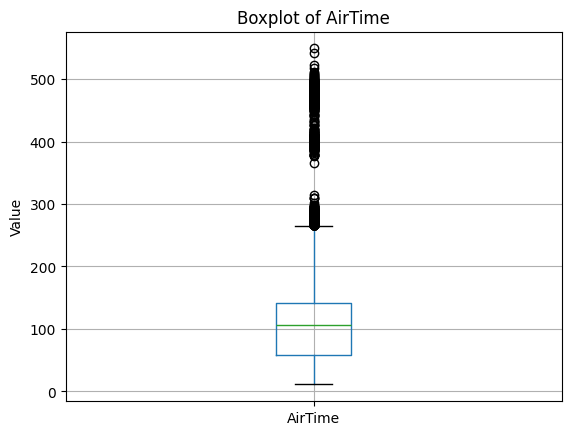

In [13]:
d4.boxplot(column=['AirTime'])
plt.title('Boxplot of AirTime')
plt.ylabel('Value')
plt.show()

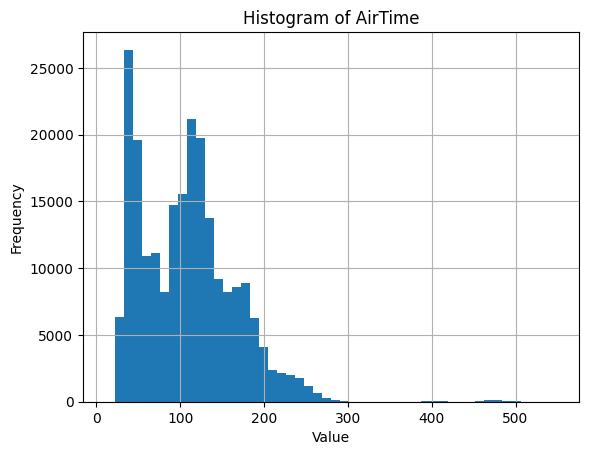

In [14]:
d4['AirTime'].hist(bins=50)  # 'bins' define the number of intervals or "buckets"
plt.title('Histogram of AirTime')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

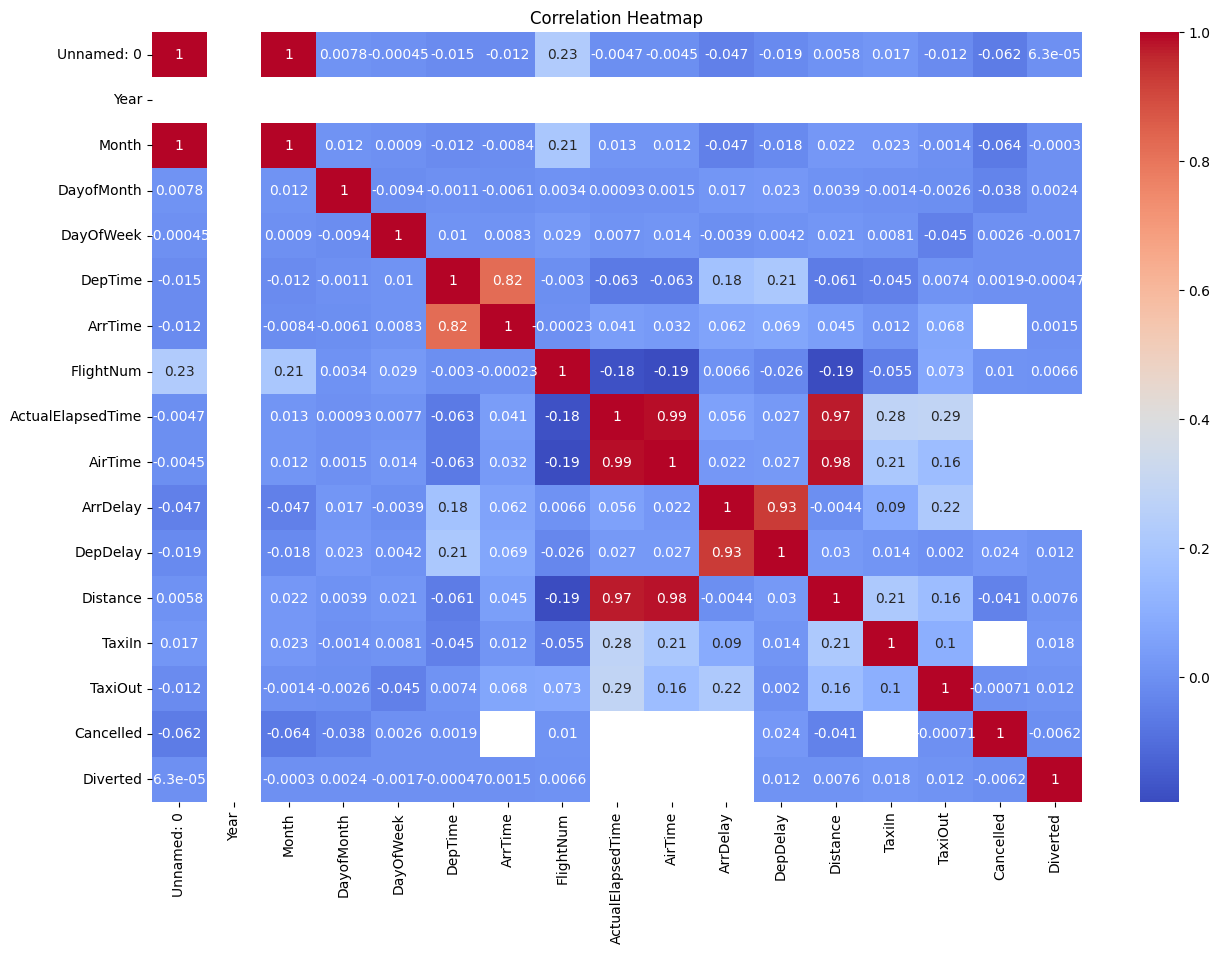

In [15]:
# Calculate the correlation matrix
correlation_matrix = hflights.select_dtypes(include=np.number).corr()

# Create a heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


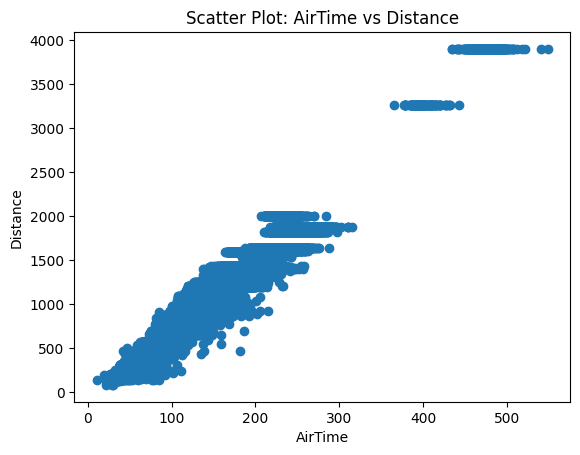

In [16]:
plt.scatter(hflights['AirTime'], hflights['Distance'])
plt.title('Scatter Plot: AirTime vs Distance')
plt.xlabel('AirTime')
plt.ylabel('Distance')
plt.show()


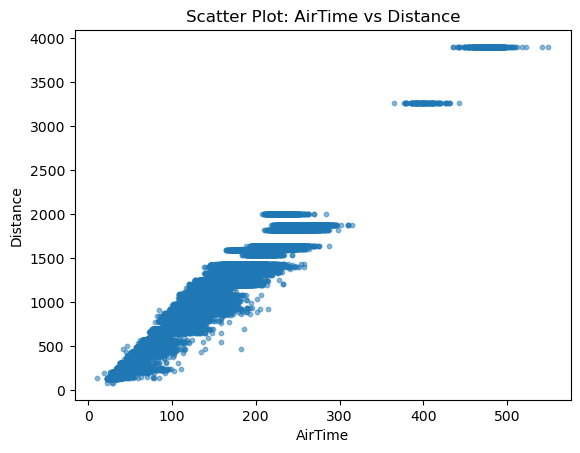

In [ ]:
plt.scatter(hflights['AirTime'], hflights['Distance'], alpha=0.5, s=10)
plt.title('Scatter Plot: AirTime vs Distance')
plt.xlabel('AirTime')
plt.ylabel('Distance')
plt.show()


In [ ]:
# 'object' typically contain strings (text) or mixed types (strings and numbers).

d5 = hflights.select_dtypes(include='object')
d5.head()

,UniqueCarrier,TailNum,Origin,Dest,CancellationCode
5424,AA,N576AA,IAH,DFW,NaN
5425,AA,N557AA,IAH,DFW,NaN
5426,AA,N541AA,IAH,DFW,NaN
5427,AA,N403AA,IAH,DFW,NaN
5428,AA,N492AA,IAH,DFW,NaN


### Filter Function

In [ ]:
# filter records which rows in the 'Distance' column have values greater than 1000.
d6 = hflights.loc[hflights['Distance'] > 1000, :]
d6.shape

(65389, 21)

In [ ]:
# check rows where the 'CancellationCode' column has the value 'D' or 'B'.
d7 = hflights.loc[(hflights['CancellationCode'] == 'D') | (hflights['CancellationCode'] == 'B'), :]
d7.shape

(1653, 21)

In [ ]:
# an alternative to d7
d8 = hflights.loc[hflights['CancellationCode'].isin(['B', 'D']), :]
d8.shape

(1653, 21)

In [ ]:
# generate a new variable called "TotalDelay", which is the sum of "ArrDelay" and "DepDelay"
hflights['TotalDelay'] = hflights['ArrDelay'] + hflights['DepDelay']
d9 = hflights.loc[hflights['TotalDelay'] > 60, :]
d9.shape
d9.head()

,Year,Month,DayofMonth,DayOfWeek,DepTime,ArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,...,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,TotalDelay
5432,2011,1,9,7,1443.0,1554.0,AA,428,N476AA,71.0,...,43.0,IAH,DFW,224,8.0,22.0,0,NaN,0,87.0
5433,2011,1,10,1,1443.0,1553.0,AA,428,N504AA,70.0,...,43.0,IAH,DFW,224,6.0,19.0,0,NaN,0,86.0
5440,2011,1,17,1,1530.0,1634.0,AA,428,N518AA,64.0,...,90.0,IAH,DFW,224,8.0,8.0,0,NaN,0,174.0
5443,2011,1,20,4,1507.0,1622.0,AA,428,N425AA,75.0,...,67.0,IAH,DFW,224,9.0,24.0,0,NaN,0,139.0
5454,2011,1,31,1,1441.0,1553.0,AA,428,N505AA,72.0,...,41.0,IAH,DFW,224,8.0,25.0,0,NaN,0,84.0


In [ ]:
d10 = hflights.loc[hflights['AirTime'] < hflights['TotalDelay'], :]
d10.head()

,Year,Month,DayofMonth,DayOfWeek,DepTime,ArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,...,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,TotalDelay
5432,2011,1,9,7,1443.0,1554.0,AA,428,N476AA,71.0,...,43.0,IAH,DFW,224,8.0,22.0,0,NaN,0,87.0
5433,2011,1,10,1,1443.0,1553.0,AA,428,N504AA,70.0,...,43.0,IAH,DFW,224,6.0,19.0,0,NaN,0,86.0
5434,2011,1,11,2,1429.0,1539.0,AA,428,N565AA,70.0,...,29.0,IAH,DFW,224,8.0,20.0,0,NaN,0,58.0
5440,2011,1,17,1,1530.0,1634.0,AA,428,N518AA,64.0,...,90.0,IAH,DFW,224,8.0,8.0,0,NaN,0,174.0
5443,2011,1,20,4,1507.0,1622.0,AA,428,N425AA,75.0,...,67.0,IAH,DFW,224,9.0,24.0,0,NaN,0,139.0


In [ ]:
d9 = hflights.loc[(hflights['ArrDelay'] + hflights['DepDelay']) > 60, :]
d10 = hflights.loc[hflights['AirTime'] < (hflights['ArrDelay'] + hflights['DepDelay']), :]

d11 = hflights.loc[hflights['AirTime'] < (hflights['ArrDelay'] + hflights['DepDelay']), :]
d12 = d11.loc[:, ['FlightNum', 'DayOfWeek', 'AirTime', 'ArrDelay', 'DepDelay']]
d12.head()

,FlightNum,DayOfWeek,AirTime,ArrDelay,DepDelay
5432,428,7,41.0,44.0,43.0
5433,428,1,45.0,43.0,43.0
5434,428,2,42.0,29.0,29.0
5440,428,1,48.0,84.0,90.0
5443,428,4,42.0,72.0,67.0


### Piping

In [ ]:
# Rename Function
d13 = hflights.rename(columns={'DepartureTime': 'DepTime', 'ArrivalTime': 'ArrTime'})
d13.head()

,Year,Month,DayofMonth,DayOfWeek,DepTime,ArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,...,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,TotalDelay
5424,2011,1,1,6,1400.0,1500.0,AA,428,N576AA,60.0,...,0.0,IAH,DFW,224,7.0,13.0,0,NaN,0,-10.0
5425,2011,1,2,7,1401.0,1501.0,AA,428,N557AA,60.0,...,1.0,IAH,DFW,224,6.0,9.0,0,NaN,0,-8.0
5426,2011,1,3,1,1352.0,1502.0,AA,428,N541AA,70.0,...,-8.0,IAH,DFW,224,5.0,17.0,0,NaN,0,-16.0
5427,2011,1,4,2,1403.0,1513.0,AA,428,N403AA,70.0,...,3.0,IAH,DFW,224,9.0,22.0,0,NaN,0,6.0
5428,2011,1,5,3,1405.0,1507.0,AA,428,N492AA,62.0,...,5.0,IAH,DFW,224,9.0,9.0,0,NaN,0,2.0


In [ ]:
# Mutate Function
d15 = hflights.copy()
d15['ActualGroundTime'] = d15['ActualElapsedTime'] - d15['AirTime']
d15['TaxiTime'] = d15['TaxiIn'] + d15['TaxiOut']
d15['AvgSpeed'] = 60 * (d15['Distance'] / d15['AirTime'])
d15.head()

,Year,Month,DayofMonth,DayOfWeek,DepTime,ArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,...,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,TotalDelay,ActualGroundTime,TaxiTime,AvgSpeed
5424,2011,1,1,6,1400.0,1500.0,AA,428,N576AA,60.0,...,224,7.0,13.0,0,NaN,0,-10.0,20.0,20.0,336.000000
5425,2011,1,2,7,1401.0,1501.0,AA,428,N557AA,60.0,...,224,6.0,9.0,0,NaN,0,-8.0,15.0,15.0,298.666667
5426,2011,1,3,1,1352.0,1502.0,AA,428,N541AA,70.0,...,224,5.0,17.0,0,NaN,0,-16.0,22.0,22.0,280.000000
5427,2011,1,4,2,1403.0,1513.0,AA,428,N403AA,70.0,...,224,9.0,22.0,0,NaN,0,6.0,31.0,31.0,344.615385
5428,2011,1,5,3,1405.0,1507.0,AA,428,N492AA,62.0,...,224,9.0,9.0,0,NaN,0,2.0,18.0,18.0,305.454545


In [ ]:
# Arrange Function
d17 = hflights.sort_values(by='AirTime')
d17.head()

,Year,Month,DayofMonth,DayOfWeek,DepTime,ArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,...,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted
4066356,2011,8,31,3,1255.0,1346.0,CO,1646,N11612,51.0,...,-7.0,0.0,IAH,AUS,140,8.0,32.0,0,NaN,0
2599099,2011,6,5,7,1145.0,1225.0,CO,405,N32626,40.0,...,-16.0,0.0,IAH,SAT,191,6.0,15.0,0,NaN,0
683596,2011,2,23,3,947.0,1030.0,XE,2204,N17928,43.0,...,29.0,32.0,IAH,BPT,79,5.0,16.0,0,NaN,0
1688984,2011,4,8,5,2017.0,2057.0,XE,2418,N14925,40.0,...,7.0,17.0,IAH,LCH,127,6.0,12.0,0,NaN,0
4334034,2011,9,20,2,728.0,833.0,XE,2507,N15572,65.0,...,3.0,-2.0,IAH,AUS,140,5.0,37.0,0,NaN,0


In [ ]:
# show complete columns
pd.set_option('display.max_columns', None)
d17.head()

,Year,Month,DayofMonth,DayOfWeek,DepTime,ArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted
4066356,2011,8,31,3,1255.0,1346.0,CO,1646,N11612,51.0,11.0,-7.0,0.0,IAH,AUS,140,8.0,32.0,0,NaN,0
2599099,2011,6,5,7,1145.0,1225.0,CO,405,N32626,40.0,19.0,-16.0,0.0,IAH,SAT,191,6.0,15.0,0,NaN,0
683596,2011,2,23,3,947.0,1030.0,XE,2204,N17928,43.0,22.0,29.0,32.0,IAH,BPT,79,5.0,16.0,0,NaN,0
1688984,2011,4,8,5,2017.0,2057.0,XE,2418,N14925,40.0,22.0,7.0,17.0,IAH,LCH,127,6.0,12.0,0,NaN,0
4334034,2011,9,20,2,728.0,833.0,XE,2507,N15572,65.0,23.0,3.0,-2.0,IAH,AUS,140,5.0,37.0,0,NaN,0


In [ ]:
# Summarize Function
s1 = hflights.groupby('UniqueCarrier').agg({'AirTime': 'mean'})
s1

,AirTime
UniqueCarrier,
AA,69.652612
AS,254.184066
B6,183.985141
CO,145.457873
DL,97.801235
EV,103.656766
F9,125.341346
FL,92.706300
MQ,93.839476


In [ ]:
# analyze the 'AirTime' for flights in the hflights DataFrame, grouping the data by carrier and origin airport.

s3 = hflights.groupby(['UniqueCarrier', 'Origin']).agg({'AirTime': ['mean', 'count', 'max']})
s3.columns = ['AvgTime', 'NumFlights', 'LongestFlightTime']
s3.reset_index(inplace=True)
s3

,UniqueCarrier,Origin,AvgTime,NumFlights,LongestFlightTime
0,AA,IAH,69.652612,3178,161.0
1,AS,IAH,254.184066,364,315.0
2,B6,HOU,183.985141,673,258.0
3,CO,IAH,145.457873,69373,549.0
4,DL,HOU,92.389785,372,135.0
5,DL,IAH,98.708427,2219,188.0
6,EV,HOU,92.879545,440,117.0
7,EV,IAH,106.477692,1681,173.0
8,F9,HOU,125.341346,832,190.0
9,FL,HOU,92.706300,2111,186.0
